# Phase 0: MSR-VTT 인덱싱 (사전 1회 실행)

역할: ShotDetector → Embedding → FAISS + BM25(English/spaCy) 인덱스 구축

> **사전 요구**: 를 먼저 실행하여 환경을 세팅하세요.
> 이 노트북은 로 CONFIG와 의존성을 자동 로드합니다.
>
> **캡션 출처**: MSR-VTT 원본 CSV의 caption/sentence 열을 그대로 사용합니다.
> (GPT API를 이용한 메타데이터 생성은 현재 사용하지 않습니다.)

In [1]:
# ── Step 0: 환경 로드 (00_setup.ipynb 실행) ──
import os, nbformat
from IPython import get_ipython

# 00_setup.ipynb 위치
SETUP_PATH = "/content/videorag_prototype/notebooks/00_setup.ipynb"

# 레포가 없으면 먼저 클론
if not os.path.exists("/content/videorag_prototype"):
    from google.colab import userdata
    # [Public repo] token 불필요 — public clone
    os.system("git clone https://github.com/LimPark996/VideoRAG-Public.git /content/videorag_prototype")
    print("✓ git clone 완료")

# 00_setup.ipynb 셀 전체 실행 (현재 커널 namespace에 주입)
with open(SETUP_PATH, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

ip = get_ipython()
for cell in nb.cells:
    if cell.cell_type == "code":
        ip.run_cell(cell.source)

# CONFIG 변수 확인
print(f"\n{'='*60}")
print(f"01_indexing: 환경 로드 완료")
print(f"  VIDEO_DIR:  {VIDEO_DIR}")
print(f"  INDEX_DIR:  {INDEX_DIR}")
print(f"{'='*60}")

In [2]:
# ── Step 0.5: InternVideo 설치 (런타임 초기화 시 1회) ─
import shutil, os

# 기존 디렉토리 삭제
if os.path.exists('/content/InternVideo'):
    shutil.rmtree('/content/InternVideo')
    print('✓ 기존 /content/InternVideo 삭제 완료')

# 다시 sparse checkout 클론
!git clone --no-checkout --depth=1 https://github.com/OpenGVLab/InternVideo.git /content/InternVideo
%cd /content/InternVideo
!git sparse-checkout init --cone
!git sparse-checkout set InternVideo2/multi_modality
!git checkout main

# 확인
print(os.listdir("/content/InternVideo/InternVideo2/multi_modality"))

✓ 기존 /content/InternVideo 삭제 완료
Cloning into '/content/InternVideo'...
remote: Enumerating objects: 2495, done.
remote: Counting objects: 100% (2495/2495), done.
remote: Compressing objects: 100% (1323/1323), done.
remote: Total 2495 (delta 1167), reused 2333 (delta 1127), pack-reused 0 (from 0)
Receiving objects: 100% (2495/2495), 29.63 MiB | 11.43 MiB/s, done.
Resolving deltas: 100% (1167/1167), done.
/content/InternVideo
Already on 'main'
Your branch is up to date with 'origin/main'.
['models', 'preprocess', 'tasks_clip', 'demo_video_text_retrieval.ipynb', 'requirements.txt', 'torchrun.sh', 'demo_config.py', 'README.md', 'scripts', 'demo', '.gitignore', '__init__.py', 'miscs', 'tools', 'configs', 'pyproject.toml', 'INSTALL.md', 'MODEL_ZOO.md', 'utils', 'tests', 'tasks', 'DATASET.md', 'dataset', 'DEMO_USAGE_GUIDE.md']


---
## ⚙️ 인덱싱 모드 선택

**Cell 3 · Cell 4 · Cell 8** 에서 모드에 맞게 한 줄씩 주석을 바꿼주세요.

| 모드 | 대상 영상 | 평가 가능 여부 | 인덱싱 시간 |
|------|-----------|--------------|-------------|
| **demo** | train+val 7010개 | ❌ (03_eval 불가) | ~7시간 |
| **eval** | 1k-A test 1000개 | ✅ R@1/R@5/R@10 정상 | ~1시간 |

### Cell 3 — 영상 복원
```python
# [demo] train+val 7010개 — msrvtt_metadata_full.csv 기준
_df = pd.read_csv(METADATA_CSV_PATH)
target_ids = set(_df['video_id'].astype(str)) & drive_vids

# [eval] 1k-A test set만
# with open(ANNOTATION_JSON) as _f: _ann = json.load(_f)
# target_ids = {s['video_id'] for s in _ann}
```

### Cell 4 — 메타데이터 CSV
```python
# [demo] train+val 전체 캐션 (7010행)
METADATA_CSV = '.../msrvtt_metadata_full.csv'

# [eval] 1k-A annotation 캐션 (1000행)
# METADATA_CSV = os.path.join(DATA_DIR, 'annotations', 'metadata_1ka.csv')
```

### Cell 8 — Drive 백업 경로
```python
# [demo]
DRIVE_BACKUP = '.../index_demo'

# [eval]
# DRIVE_BACKUP = '.../index_eval'
```

> 두 인덱스를 별도 폴더로 백업해두면 모드 전환 시 재빌드 없이 교체 가능합니다.
---


In [3]:
import os, zipfile, json, shutil, urllib.request
import pandas as pd

# ── 1. 영상 ID 목록 준비 ──
ANNOTATION_JSON = '/content/videorag_prototype/data/msrvtt/annotations/msrvtt_test_1k.json'
VIDEO_DIR    = '/content/videorag_prototype/data/msrvtt/videos'
DRIVE_VIDEOS = '/content/drive/MyDrive/videorag_prototype/data/msrvtt/videos'
HF_ZIP_URL   = 'https://huggingface.co/datasets/friedrichor/MSR-VTT/resolve/main/MSRVTT_Videos.zip'
HF_ZIP_PATH  = '/content/MSRVTT_Videos.zip'

METADATA_CSV_PATH = '/content/drive/MyDrive/videorag_prototype/data/msrvtt/videos/msrvtt_captions/msrvtt_metadata_full.csv'

os.makedirs(VIDEO_DIR, exist_ok=True)

drive_vids = set()
if os.path.exists(DRIVE_VIDEOS):
    drive_vids = {f[:-4] for f in os.listdir(DRIVE_VIDEOS) if f.endswith('.mp4')}

# ── [현재: demo 모드] train+val — msrvtt_metadata_full.csv 기준 ──
_df = pd.read_csv(METADATA_CSV_PATH)
target_ids = set(_df['video_id'].astype(str)) & drive_vids
# ── [eval 모드] 1k-A test set만 복원 ──
# with open(ANNOTATION_JSON) as _f: _ann = json.load(_f)
# target_ids = {s['video_id'] for s in _ann}

print(f'인덱싱 대상: {len(target_ids)}개')

# ── 2. Drive → VIDEO_DIR 심링크/복사 ──
if drive_vids:
    copied, skipped = 0, 0
    for vid in target_ids:
        src_p = os.path.join(DRIVE_VIDEOS, f'{vid}.mp4')
        dst_p = os.path.join(VIDEO_DIR, f'{vid}.mp4')
        if not os.path.exists(dst_p):
            if os.path.exists(src_p):
                try:
                    os.symlink(src_p, dst_p)
                except OSError:
                    shutil.copy2(src_p, dst_p)
                copied += 1
        else:
            skipped += 1
    print(f'Drive 연결: {copied}개 신규, {skipped}개 이미 존재')

# ── 3. 부족한 영상 HuggingFace zip 폴백 ──
have_now = {f[:-4] for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')} & target_ids
missing  = sorted(target_ids - have_now)
if missing:
    print(f'⚠ {len(missing)}개 부족 → HuggingFace에서 다운로드 중...')
    if not os.path.exists(HF_ZIP_PATH):
        urllib.request.urlretrieve(HF_ZIP_URL, HF_ZIP_PATH)
        print('다운로드 완료')
    missing_set = set(missing)
    extracted = 0
    with zipfile.ZipFile(HF_ZIP_PATH) as zf:
        for member in zf.namelist():
            name = os.path.basename(member)
            if not name.endswith('.mp4') or name[:-4] not in missing_set:
                continue
            dst_p = os.path.join(VIDEO_DIR, name)
            if os.path.exists(dst_p) and os.path.getsize(dst_p) > 0:
                continue
            with zf.open(member) as s, open(dst_p, 'wb') as o:
                shutil.copyfileobj(s, o)
            extracted += 1
    print(f'zip 추출 완료: {extracted}개')

# ── 4. 최종 검증 ──
have_final    = {f[:-4] for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')} & target_ids
still_missing = sorted(target_ids - have_final)
print(f'복원 완료: {len(have_final)}개 / {len(target_ids)}개')
if still_missing:
    print(f'  ⚠ 누락: {still_missing[:5]}{"..." if len(still_missing)>5 else ""}')
else:
    print('  → 인덱싱 준비 완료')


In [4]:
# ── Step 1: 경로 설정 & import ──
import sys, os

PROJECT_ROOT = '/content/videorag_prototype'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'msrvtt')
VIDEO_DIR    = os.path.join(DATA_DIR, 'videos')
KEYFRAME_DIR = os.path.join(DATA_DIR, 'keyframes')
INDEX_DIR    = os.path.join(PROJECT_ROOT, 'index')

# ── 메타데이터 CSV ──
# [현재: demo 모드] train+val 전체 캡션 (7010행, Drive)
METADATA_CSV = '/content/drive/MyDrive/videorag_prototype/data/msrvtt/videos/msrvtt_captions/msrvtt_metadata_full.csv'
# [eval 모드]
# METADATA_CSV = os.path.join(DATA_DIR, 'annotations', 'metadata_1ka.csv')

for d in [DATA_DIR, VIDEO_DIR, KEYFRAME_DIR, INDEX_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'PROJECT_ROOT   : {PROJECT_ROOT}')
print(f'VIDEO_DIR      : {VIDEO_DIR}')
print(f'INDEX_DIR      : {INDEX_DIR}')
print(f'METADATA_CSV   : {METADATA_CSV}')
print(f'CSV 존재       : {os.path.exists(METADATA_CSV)}')

if os.path.exists(VIDEO_DIR):
    vids = [f for f in os.listdir(VIDEO_DIR) if f.endswith(('.mp4','.avi','.mkv'))]
    print(f'영상 파일 수    : {len(vids)}')
else:
    print('⚠ VIDEO_DIR 없음')


In [5]:
from src.phase0_indexing.shot_detector import ShotDetector
from src.phase0_indexing.embedder import VideoEmbedder
from src.phase0_indexing.vector_store import FAISSVectorStore
from src.phase0_indexing.indexer import VideoIndexer

shot_detector = ShotDetector()
embedder      = VideoEmbedder(num_frames=4)          # ← num_frames 추가
vector_store  = FAISSVectorStore(dim=512)             # ← 1024 → 512 (InternVideo2 embed_dim=512)

indexer = VideoIndexer(
    shot_detector=shot_detector,
    embedder=embedder,
    vector_store=vector_store,
    index_dir=INDEX_DIR,
    keyframe_dir=KEYFRAME_DIR,
    tokenizer_mode='spacy',                          # ← v2: korean → spacy
    num_frames=4                                      # ← num_frames 추가
)

print('✓ VideoIndexer 초기화 완료')
print(f'  Shot Detector : {type(shot_detector).__name__}')
print(f'  Embedder      : {type(embedder).__name__}')
print(f'  Vector Store  : {type(vector_store).__name__} (dim=512)')  # ← 512로 수정
print(f'  Tokenizer     : spaCy (English)')


[TransNetV2] Using weights from /content/TransNetV2/inference/transnetv2-weights/.

🤖 [VideoEmbedder 초기화]
   model_name : OpenGVLab/InternVideo2-Stage2_1B-224p-f4
   device     : cuda
   use_fp16   : True  (VRAM 절약용, cuda일 때만 활성)
   num_frames : 4  (클립당 인코딩 프레임 수)
✓ VideoIndexer 초기화 완료
  Shot Detector : ShotDetector
  Embedder      : VideoEmbedder
  Vector Store  : FAISSVectorStore (dim=512)
  Tokenizer     : spaCy (English)


In [6]:
import sys
sys.path.insert(0, '/content/InternVideo/InternVideo2/multi_modality')

# ── flash_attn 더미 + relative import 패치 (embedder 밖에서 직접 테스트할 때) ──
from src.phase0_indexing.embedder import VideoEmbedder
VideoEmbedder._inject_flash_attn_stub()
VideoEmbedder._patch_internvideo2_source()

# 직접 import 테스트
from demo.utils import setup_internvideo2, frames2tensor
print("✓ import 성공")

   flash_attn 더미 모듈 주입 완료 (use_flash_attn=False → 실제 호출 없음)
   소스 패치 적용: ['__init__.py', 'criterions.py', 'utils.py']
   소스 패치 적용: xbert.py (transformers 호환 레이어 삽입)
   소스 패치 적용: xbert.py (_tied_weights_keys 추가)


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/InternVideo/InternVideo2/multi_modality/models/backbones/internvideo2/internvl_clip_vision.py:148: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/content/InternVideo/InternVideo2/multi_modality/models/backbones/internvideo2/internvideo2.py:148: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Import

No module named 'deepspeed'
deepspeed is not installed!!!
✓ import 성공


In [8]:
# ── Step 3: 인덱싱 실행 ──
import time
import pandas as pd
from google.colab import userdata
import os

# 환경변수에 넣어주면 transformers가 자동으로 읽음
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

# ── 사전 확인 ──
print('='*50)
print('📋 인덱싱 사전 확인')
print('='*50)

# 영상 수 확인
video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith(('.mp4', '.avi', '.mkv'))]
print(f'🎬 인덱싱 대상 영상 수 : {len(video_files)}개')
print(f'📁 영상 디렉토리       : {VIDEO_DIR}')
print(f'📄 메타데이터 CSV      : {METADATA_CSV}')
print(f'CSV 존재              : {os.path.exists(METADATA_CSV)}')
print(f'⚙️  캡션 출처           : MSR-VTT 원본 CSV (caption/sentence 열)')
print()

# 영상 목록 샘플 미리보기
print(f'🎥 영상 샘플 (상위 5개):')
for v in sorted(video_files)[:5]:
    fpath = os.path.join(VIDEO_DIR, v)
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    print(f'   {v} ({size_mb:.1f} MB)')
print()

# 예상 소요 시간 (영상당 평균 5초 가정)
est_sec = len(video_files) * 5
print(f'⏱️  예상 소요 시간      : 약 {est_sec//60}분 {est_sec%60}초 (영상당 ~5초 기준)')
print('='*50)
print()

# ── 인덱싱 실행 ──
input('▶ Enter를 누르면 인덱싱을 시작합니다...')

start = time.perf_counter()

from tqdm.notebook import tqdm

print('🚀 인덱싱 시작...')

result = indexer.build_index(
    video_dir=VIDEO_DIR,
    metadata_csv=METADATA_CSV,  # MSR-VTT 원본 캡션 CSV
    max_clips=None
)

elapsed = time.perf_counter() - start

print(f'{"="*50}')
print(f'✅ 인덱싱 완료!')
print(f'  클립 수       : {result.n_clips}')
print(f'  벡터 수       : {result.n_vectors}')
print(f'  FAISS 인덱스  : {result.faiss_index_path}')
print(f'  BM25 인덱스   : {result.bm25_index_path}')
print(f'  메타데이터    : {result.metadata_path}')
print(f'  소요 시간     : {elapsed:.1f}초 ({elapsed/len(video_files):.1f}초/영상)')
print(f'{"="*50}')


In [10]:
# ── 인덱싱 완료 후 즉시 실행: Drive 백업 ──
import shutil, os

# [현재: demo 모드]
DRIVE_BACKUP = '/content/drive/MyDrive/videorag_prototype/index_demo'
# [eval 모드]
# DRIVE_BACKUP = '/content/drive/MyDrive/videorag_prototype/index_eval'
LOCAL_INDEX  = '/content/videorag_prototype/index'

os.makedirs(DRIVE_BACKUP, exist_ok=True)

# 기존 백업 덮어쓰기
if os.path.exists(DRIVE_BACKUP):
    shutil.rmtree(DRIVE_BACKUP)

shutil.copytree(LOCAL_INDEX, DRIVE_BACKUP)
print(f'✅ Drive 백업 완료: {DRIVE_BACKUP}')
print(f'   파일 목록: {os.listdir(DRIVE_BACKUP)}')

# 키프레임 백업
DRIVE_KF = '/content/drive/MyDrive/videorag_prototype/keyframes'
os.makedirs(DRIVE_KF, exist_ok=True)
if os.path.exists(DRIVE_KF):
    shutil.rmtree(DRIVE_KF)
shutil.copytree('/content/videorag_prototype/data/msrvtt/keyframes', DRIVE_KF)
print('✅ 키프레임 백업 완료')

# ── 영상 파일 Drive 백업 (02_demo에서 영상 합성에 필수) ──
DRIVE_VIDEOS = '/content/drive/MyDrive/videorag_prototype/data/msrvtt/videos'
LOCAL_VIDEOS = '/content/videorag_prototype/data/msrvtt/videos'

if os.path.exists(LOCAL_VIDEOS):
    os.makedirs(DRIVE_VIDEOS, exist_ok=True)
    local_mp4s = [f for f in os.listdir(LOCAL_VIDEOS) if f.endswith('.mp4')]
    # Drive에 이미 있는 파일은 스킵
    existing = set(os.listdir(DRIVE_VIDEOS)) if os.path.exists(DRIVE_VIDEOS) else set()
    to_copy = [f for f in local_mp4s if f not in existing]

    for i, f in enumerate(to_copy):
        shutil.copy2(os.path.join(LOCAL_VIDEOS, f), os.path.join(DRIVE_VIDEOS, f))
        if (i + 1) % 200 == 0:
            print(f'   영상 복사 중: {i+1}/{len(to_copy)}')

    print(f'✅ 영상 Drive 백업 완료: {len(local_mp4s)}개 ({len(to_copy)}개 신규 복사)')
    print(f'   경로: {DRIVE_VIDEOS}')
else:
    print('⚠ 로컬 영상 디렉토리 없음 — 영상 백업 건너뜀')


✅ Drive 백업 완료: /content/drive/MyDrive/videorag_prototype/index
   파일 목록: ['bm25_index.pkl', 'faiss_ivfflat.index.ids.pkl', 'faiss_ivfflat.index', 'clip_metadata.pkl']
✅ 키프레임 백업 완료
✅ 영상 Drive 백업 완료: 1000개 (0개 신규 복사)
   경로: /content/drive/MyDrive/videorag_prototype/data/msrvtt/videos


In [ ]:
# ── Step 3.5: ITM Vision Feature 사전 추출 (ColBERT 이후 ITM 재순위용) ──
#
# 목적:
#   ColBERT가 텍스트 기반으로 상위 k개를 추린 다음, ITM cross-attention으로 최종 재순위.
#   쿼리 타임에 영상을 다시 인코딩하면 1클립당 ~0.35초 → 전체 재실행이 너무 무거움.
#   → 인덱싱 시점에 vision full token [N, 1025, 1408]을 미리 추출해서 저장.
#
# 저장 파일: {INDEX_DIR}/itm_vision_features.pt
#   {'clip_ids': List[str], 'features': Tensor[N, 1025, 1408] fp16}
#   용량 예시: 1000클립 ≈ 2.9GB (fp16)
#
# 소요 시간: T4 기준 1000클립 ≈ 6분
#   (인덱싱 Step 3의 ITC 임베딩과 별도 실행 — 여기서는 full token 추출)
#
# ⚠️  GPU 메모리 주의: OOM 발생 시 batch_size=2로 낮추세요.

import time

print("=" * 60)
print("Step 3.5: ITM Vision Feature 추출 시작")
print("=" * 60)
print(f"  대상 인덱스: {INDEX_DIR}")
print(f"  저장 파일  : {INDEX_DIR}/itm_vision_features.pt")
print()

t0 = time.time()

itm_feat_path = indexer.build_itm_vision_features(
    video_dir=VIDEO_DIR,
    metadata_csv=METADATA_CSV if os.path.exists(METADATA_CSV) else None,
    batch_size=4,       # OOM 발생 시 2로 낮추기
)

elapsed = time.time() - t0
print(f"\n✅ ITM feature 추출 완료 (소요: {elapsed/60:.1f}분)")
print(f"   저장 경로: {itm_feat_path}")

# Drive 백업
import shutil
DRIVE_ITM = '/content/drive/MyDrive/videorag_prototype/index/itm_vision_features.pt'
shutil.copy2(itm_feat_path, DRIVE_ITM)
print(f"   Drive 백업: {DRIVE_ITM}")


In [ ]:
!apt-get install -q ffmpeg
!pip install -q ffmpeg-python

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
from src.phase0_indexing.shot_detector import ShotDetector, SceneInfo

detector = ShotDetector()

try:
    from transnetv2 import TransNetV2
    print("✅ TransNetV2 설치됨")
except ImportError:
    print("❌ TransNetV2 미설치 — 폴백(균등분할) 모드로 동작")

sample_videos = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')][5:6]

if sample_videos:
    sample_path = os.path.join(VIDEO_DIR, sample_videos[0])
    print(f'샘플 영상: {sample_videos[0]}')

    shots = detector.detect_shots(sample_path)
    print(f'  Shot 수: {len(shots)}')

    if len(shots) >= 2:
        scenes = detector.detect_scenes(sample_path)  # shots 인자 제거
        print(f'  Scene 수: {len(scenes)}')
        for sc in scenes:
            print(f'    Scene {sc.scene_id}: Shot {len(sc.shots)}개 '
                  f'({sc.start_ms:.0f}ms ~ {sc.end_ms:.0f}ms)')  # shot_indices → len(sc.shots)
    else:
        print('  Shot 2개 미만 → Scene 그룹화 생략')
else:
    print('⚠ 영상 파일 없음')

[TransNetV2] Using weights from /content/TransNetV2/inference/transnetv2-weights/.
✅ TransNetV2 설치됨
샘플 영상: video6263.mp4
[TransNetV2] Extracting frames from /content/videorag_prototype/data/msrvtt/videos/video6263.mp4
[TransNetV2] Processing video frames 264/264
  Shot 수: 6
[TransNetV2] Extracting frames from /content/videorag_prototype/data/msrvtt/videos/video6263.mp4
[TransNetV2] Processing video frames 264/264
  Scene 수: 2
    Scene 0: Shot 5개 (0ms ~ 8800ms)
    Scene 1: Shot 1개 (8842ms ~ 10969ms)


In [ ]:
import cv2, base64, os
from IPython.display import HTML, display
from src.phase0_indexing.shot_detector import ShotDetector

detector = ShotDetector()

# ── 영상 한 개 골라서 ──
sample_path = os.path.join(VIDEO_DIR, [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mp4')][5])

def frame_to_b64(video_path, ms):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_MSEC, ms)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return ""
    _, buf = cv2.imencode(".jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
    return base64.b64encode(buf).decode()

def ms_str(ms):
    s = ms / 1000
    return f"{int(s//60):02d}:{s%60:04.1f}"

[TransNetV2] Using weights from /content/TransNetV2/inference/transnetv2-weights/.


[TransNetV2] Extracting frames from /content/videorag_prototype/data/msrvtt/videos/video6263.mp4
[TransNetV2] Processing video frames 264/264



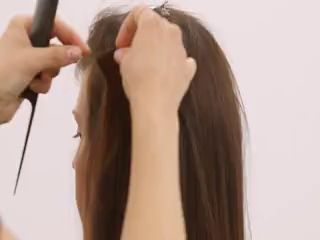
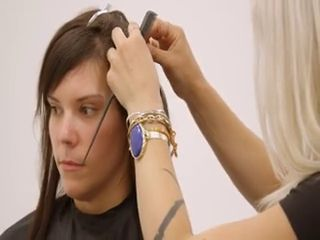
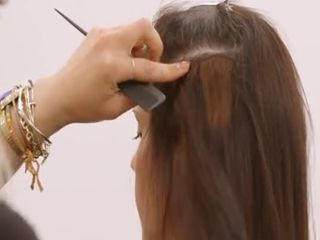
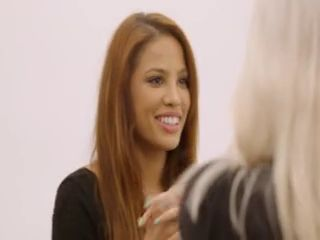
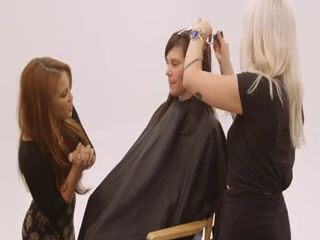
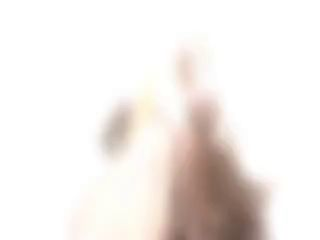

In [ ]:
shots = detector.detect_shots(sample_path)

cards = ""
for i, (start_ms, end_ms) in enumerate(shots):
    mid_ms = (start_ms + end_ms) / 2
    b64 = frame_to_b64(sample_path, mid_ms)
    cards += f"""
    <div style="display:inline-block;margin:6px;border:1px solid #333;border-radius:6px;overflow:hidden;width:160px;vertical-align:top;background:#111">
      <img src="data:image/jpeg;base64,{b64}" style="width:100%;height:90px;object-fit:cover;display:block">
      <div style="padding:5px 6px;font-size:11px;color:#ccc;font-family:monospace">
        <b style="color:#7cf">Shot {i}</b><br>
        {ms_str(start_ms)} ~ {ms_str(end_ms)}<br>
      </div>
    </div>"""

display(HTML(f"<div style='background:#0a0a0a;padding:10px;border-radius:8px'><b style='color:#fff'>Shot 결과 ({len(shots)}개)</b><br><br>{cards}</div>"))

[TransNetV2] Extracting frames from /content/videorag_prototype/data/msrvtt/videos/video6263.mp4
[TransNetV2] Processing video frames 264/264



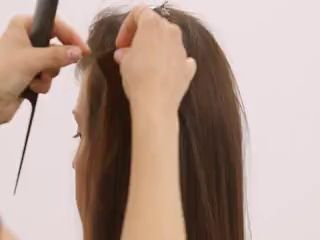
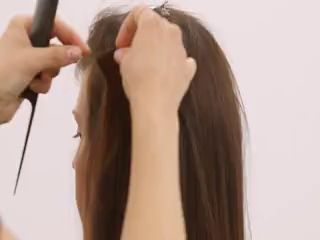
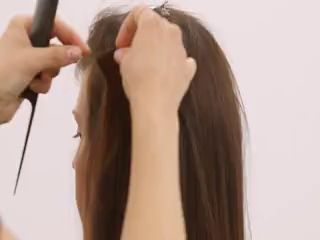
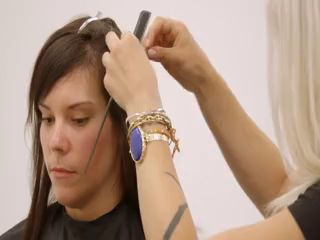
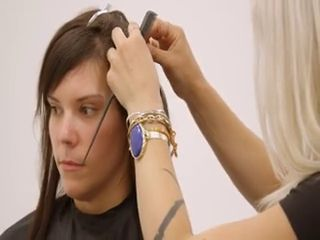
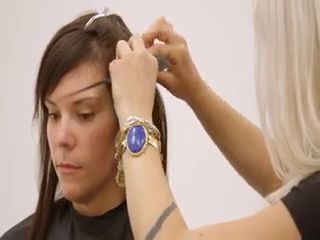
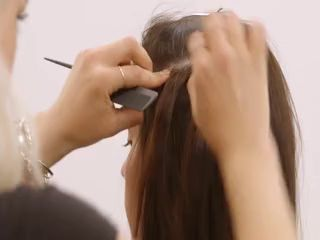
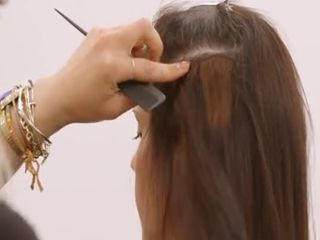
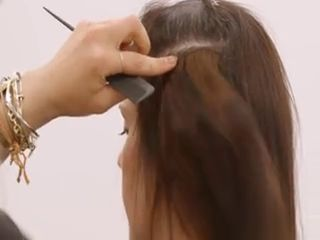
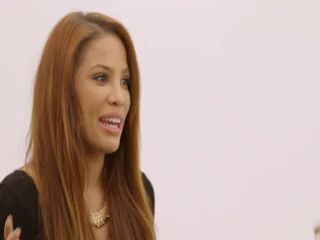
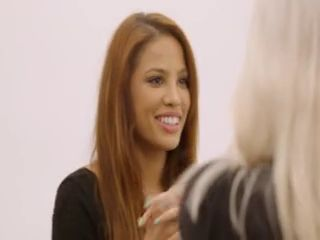
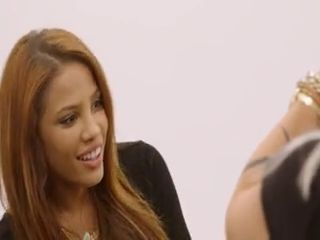
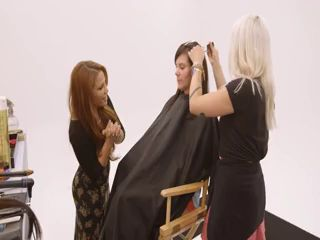
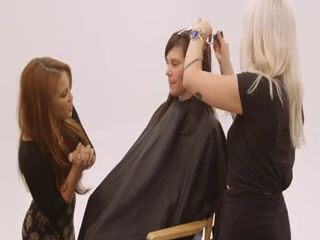
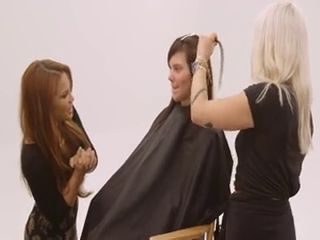
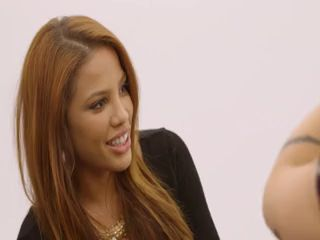
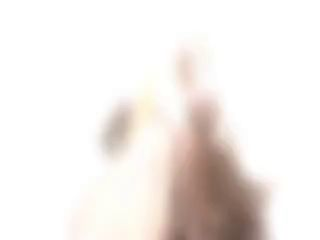
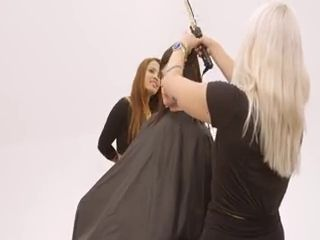

In [ ]:
scenes = detector.detect_scenes(sample_path)

SCENE_COLORS = ["#FF6B6B","#4ECDC4","#FFE66D","#A8E6CF","#C7CEEA","#FFB347"]
html = ""

for sc in scenes:
    color = SCENE_COLORS[sc.scene_id % len(SCENE_COLORS)]
    cards = ""
    for shot in sc.shots:
        for label, ms in [("첫", shot.start_ms), ("중간", (shot.start_ms+shot.end_ms)/2), ("끝", shot.end_ms)]:
            b64 = frame_to_b64(sample_path, ms)
            cards += f"""
            <div style="display:inline-block;margin:4px;text-align:center;width:110px">
              <img src="data:image/jpeg;base64,{b64}" style="width:110px;height:62px;object-fit:cover;border-radius:4px;border:1px solid #333">
              <div style="font-size:10px;color:#aaa;font-family:monospace">Shot{shot.shot_id} {label}<br>{ms_str(ms)}</div>
            </div>"""

    html += f"""
    <div style="margin-bottom:14px;border-left:3px solid {color};padding-left:10px">
      <div style="font-size:12px;font-weight:bold;color:{color};margin-bottom:6px">
        Scene {sc.scene_id} &nbsp;|&nbsp; {ms_str(sc.start_ms)} ~ {ms_str(sc.end_ms)} &nbsp;|&nbsp; Shot {len(sc.shots)}개
      </div>
      {cards}
    </div>"""

display(HTML(f"<div style='background:#0a0a0a;padding:12px;border-radius:8px'><b style='color:#fff'>Scene 결과 ({len(scenes)}개)</b><br><br>{html}</div>"))

In [ ]:
# ── Step 5: spaCy Lemmatizer BM25 토크나이저 검증 ──
# v2: en_query single path with spaCy tokenizer
from src.phase12_search.bm25_retriever import SpacyLemmatizerTokenizer

# ── 5-1: 영문 예시 (spaCy Lemmatizer) ──
print("=" * 60)
print("📌 영문 토크나이저: SpacyLemmatizerTokenizer (en_core_web_sm)")
print("=" * 60)

en_tokenizer = SpacyLemmatizerTokenizer()

en_test_cases = [
    ('a man playing guitar', 'play guitar'),
    ('woman cooking food', 'cook'),
    ('children running in park', 'run'),
]

for caption, query in en_test_cases:
    cap_tokens = en_tokenizer.tokenize(caption)
    qry_tokens = en_tokenizer.tokenize(query)
    shared = set(cap_tokens) & set(qry_tokens)
    print(f'Caption: \"{caption}\"')
    print(f'  → Lemma: {cap_tokens}')
    print(f'Query:   \"{query}\"')
    print(f'  → Lemma: {qry_tokens}')
    print(f'  공유: {shared}')
    print()

print("✅ v2는 en_query 단일 경로로 spaCy를 사용합니다.")
print()



In [ ]:
# ── Step 6: 인덱스 로드 검증 ──
import pickle

# FAISS 검증
faiss_path = os.path.join(INDEX_DIR, 'faiss_ivfflat.index')
if os.path.exists(faiss_path):
    test_vs = FAISSVectorStore(dim=512)   # ← 1024 → 512 (InternVideo2 embed_dim)
    test_vs.load(faiss_path)
    print(f'✓ FAISS 로드 성공: {test_vs.ntotal} vectors')
else:
    print(f'⚠ FAISS 인덱스 없음: {faiss_path}')

# BM25 검증
bm25_path = os.path.join(INDEX_DIR, 'bm25_index.pkl')
if os.path.exists(bm25_path):
    from src.phase12_search.bm25_retriever import BM25Retriever
    bm25 = BM25Retriever()
    bm25.load(bm25_path)
    print(f'✓ BM25 로드 성공: {len(bm25.clip_ids)} docs')
else:
    print(f'⚠ BM25 인덱스 없음: {bm25_path}')

# 메타데이터 검증
meta_path = os.path.join(INDEX_DIR, 'clip_metadata.pkl')
if os.path.exists(meta_path):
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    print(f'✓ 메타데이터 로드 성공: {len(meta)} clips')
    # 샘플 출력
    sample_id = list(meta.keys())[0]
    sample = meta[sample_id]
    print(f'  샘플: {sample_id} → "{sample.caption[:50]}..."')
else:
    print(f'⚠ 메타데이터 없음: {meta_path}')

# Drive 백업
DRIVE_INDEX = '/content/drive/MyDrive/videorag_prototype/index'
if os.path.exists('/content/drive'):
    import shutil
    os.makedirs(DRIVE_INDEX, exist_ok=True)
    for f in os.listdir(INDEX_DIR):
        src = os.path.join(INDEX_DIR, f)
        dst = os.path.join(DRIVE_INDEX, f)
        shutil.copy2(src, dst)
    print(f'\n✓ 인덱스 Drive 백업 완료: {DRIVE_INDEX}')

print('\n✓ Phase 0 인덱싱 완료 — 02_demo.ipynb로 진행하세요')

✓ FAISS 로드 성공: 1000 vectors
✓ BM25 로드 성공: 1000 docs
✓ 메타데이터 로드 성공: 1000 clips
  샘플: video950 → "A woman with curly hair applies skincare while sea..."

✓ 인덱스 Drive 백업 완료: /content/drive/MyDrive/videorag_prototype/index

✓ Phase 0 인덱싱 완료 — 02_demo.ipynb로 진행하세요
